# 실습 2

## `State`
```py
{
    # 초기 입력 데이터 2개. (위도 경도)
    'lat': 37,
    'lon': 126,

    # Open Weather API가 제공한 데이터 그대로 state에 저장
    'weather_data': {...}

    # Structured Output LLM 노드로 아래와 같이 구성
    'analysis': {
        'summary': '현재 날씨는 ...,
        'PoP': 37,  # 강수확률(Probability of precipitation)
        'temp': 28,  # 온도
        # 기타 원하는 정보
    }
}
```

In [4]:
import os
import requests
from dotenv import load_dotenv
from typing import TypedDict
from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

load_dotenv()

# LLM 모델 초기화
llm = init_chat_model('openai:gpt-4.1-mini')

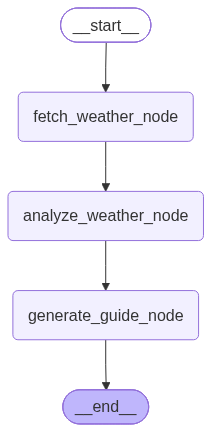

In [7]:

# ---------------------------------------------------------
# 1. Structured Output용 Pydantic 모델 정의
# ---------------------------------------------------------

class WeatherAnalysis(BaseModel):
    summary: str = Field(description="현재 날씨 상황에 대한 자연스러운 종합 요약 문장")
    PoP: int = Field(description="강수확률(0~100 사이의 정수, API 데이터 기반 추정 또는 값)")
    temp: float = Field(description="현재 기온(섭씨 °C)")
    humidity: int = Field(description="현재 습도(%)")
    recommendation: str = Field(description="현재 날씨에 맞는 옷차림이나 외출/활동 팁")


# ---------------------------------------------------------
# 2. State 정의
# ---------------------------------------------------------

class WeatherState(TypedDict):
    lat: float                  # 위도 (Latitude)
    lon: float                  # 경도 (Longitude)
    weather_data: dict          # OpenWeather API 원본 응답 데이터
    analysis: dict              # Structured Output으로 분석된 날씨 결과
    answer: str                 # 사용자에게 보여줄 최종 안내문


# ---------------------------------------------------------
# 3. Node 함수 정의
# ---------------------------------------------------------

def fetch_weather_node(state: WeatherState):
    """Node 1: OpenWeather API를 호출해 날씨 원본 데이터를 가져오는 노드"""
    lat = state['lat']
    lon = state['lon']
    
    # .env 파일에 OPENWEATHER_API_KEY가 설정되어 있어야 합니다.
    api_key = os.getenv("OPENWEATHER_API_KEY")
    url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={api_key}&units=metric&lang=kr"
    
    response = requests.get(url)
    data = response.json()
    
    return {'weather_data': data}


def analyze_weather_node(state: WeatherState):
    """Node 2: API 원본 데이터를 LLM(Structured Output)으로 분석 및 정제하는 노드"""
    weather_data = state['weather_data']
    
    system_msg = """너는 기상 데이터 분석 전문가야.
주어진 날씨 원본 JSON 데이터를 분석해서 다음 정보를 정확하게 추출/작성해줘:
1. summary: 날씨 종합 요약
2. PoP: 강수확률(%) - 데이터에 명시되지 않은 경우 날씨 상태(비, 흐림, 맑음 등)를 고려해 0~100 사이 값 추정
3. temp: 현재 기온 (°C)
4. humidity: 습도 (%)
5. recommendation: 날씨에 따른 옷차림 및 행동 추천
"""

    structured_llm = llm.with_structured_output(WeatherAnalysis)
    
    result = structured_llm.invoke([
        SystemMessage(system_msg),
        HumanMessage(f"날씨 원본 데이터: {weather_data}")
    ])
    
    # Pydantic 객체를 딕셔너리로 변환해 State에 저장
    return {'analysis': result.model_dump()}


def generate_guide_node(state: WeatherState):
    """Node 3: 분석된 결과를 바탕으로 사용자 친화적인 최종 안내문 작성 노드"""
    analysis = state['analysis']
    
    prompt = f"""아래 날씨 분석 결과를 바탕으로 사용자에게 친절하고 깔끔한 기상 안내 브리핑을 작성해줘.

- 날씨 요약: {analysis.get('summary')}
- 현재 기온: {analysis.get('temp')}°C
- 강수확률: {analysis.get('PoP')}%
- 습도: {analysis.get('humidity')}%
- 추천 사항: {analysis.get('recommendation')}
"""

    result = llm.invoke([
        SystemMessage('너는 친절한 기상 캐스터야. 이모지를 적절히 사용해 보기 편하게 안내문을 작성해줘.'),
        HumanMessage(prompt)
    ])
    
    return {'answer': result.content}


# ---------------------------------------------------------
# 4. Graph 조립 및 컴파일
# ---------------------------------------------------------

builder = StateGraph(WeatherState)

# 노드 등록 (함수명 단독 사용)
builder.add_node(fetch_weather_node)
builder.add_node(analyze_weather_node)
builder.add_node(generate_guide_node)

# Edge 연결
builder.add_edge(START, 'fetch_weather_node')
builder.add_edge('fetch_weather_node', 'analyze_weather_node')
builder.add_edge('analyze_weather_node', 'generate_guide_node')
builder.add_edge('generate_guide_node', END)

graph = builder.compile()
graph


In [9]:
# 서울 기준 (위도 37.5665, 경도 126.9780) 테스트
graph_result = graph.invoke({
    'lat': 35.1885,
    'lon': 129.0700
})

print("=== [분석된 구조화 데이터 (analysis)] ===")
print(graph_result['analysis'])

print("\n=== [최종 날씨 안내문] ===")
print(graph_result['answer'])

=== [분석된 구조화 데이터 (analysis)] ===
{'summary': '부산 지역은 온흐림인 흐린 날씨가 지속되고 있으며, 구름으로 인한 일사량 감소가 예상됩니다.', 'PoP': 20, 'temp': 30.94, 'humidity': 66, 'recommendation': '기온이 높고 습도가 다소 높은 무더운 날씨이므로, 가볍고 통기성이 좋은 옷차림을 권장합니다. 외출 시 수분 섭취를 충분히 하며, 야외 활동 시 그늘을 이용하는 것이 좋습니다.'}

=== [최종 날씨 안내문] ===
📢 안녕하세요! 부산 지역 오늘의 날씨 안내드립니다. 

🌥️ 현재 부산은 온흐림 상태의 흐린 날씨가 이어지고 있습니다. 구름이 많아 햇빛이 약해지면서 일사량이 줄어들 전망이에요.

🌡️ 현재 기온은 30.9°C로 꽤 높은 편이며, 습도도 66%로 다소 습한 무더위가 예상됩니다.

🌧️ 강수확률은 20%로, 소나기 가능성은 낮지만 간간이 빗방울이 떨어질 수도 있어요.

👕 오늘은 기온과 습도가 높으니 가볍고 통기성이 좋은 옷차림을 추천드립니다. 외출하실 땐 물을 자주 마시고, 야외 활동 시 그늘을 이용해 건강 관리에 유의하세요!

안전하고 쾌적한 하루 보내시길 바랍니다! ☀️💧
